# 🔍 Notebook 3: Finding the Difference Between Two Replicas

Now suppose two replicas of a database hold *almost* the same data — say, ~1000 keys each, with only a handful differing. We want to figure out **which keys differ**, using as little network traffic as possible. This is called **anti-entropy**, and it's what Cassandra and DynamoDB actually do in the background.

We compare three approaches:

1. 🟥 **Bad** — ship all keys/values from one replica to the other. `O(N)` traffic.
2. 🟨 **OK**  — ship a hash of every key. Smaller, but still `O(N)` hashes.
3. 🟩 **Best** — Merkle-tree walk: only descend into branches whose roots disagree. `O(K log N)` traffic, where `K` is the number of differing keys.

## Learning objectives
- Compare the three strategies on the same dataset.
- Understand why Merkle wins when replicas are *mostly* equal.
- Handle non-power-of-two leaf counts correctly.

In [1]:
import hashlib, random
random.seed(0)

def H_leaf(data: bytes) -> bytes:
    return hashlib.sha256(b'\x00' + data).digest()

def H_node(left: bytes, right: bytes) -> bytes:
    return hashlib.sha256(b'\x01' + left + right).digest()

# Deliberately pick N that is NOT a power of two, to exercise padding.
N = 1000
DIFFS = 5

base = [(f'key{i:04d}', f'value{i}') for i in range(N)]
replica_A = list(base)
replica_B = list(base)
diff_indices = random.sample(range(N), DIFFS)
for i in diff_indices:
    k, v = replica_B[i]
    replica_B[i] = (k, v + '_modified')

# Both replicas must agree on leaf order. Sorting by key is the canonical choice.
replica_A.sort()
replica_B.sort()
print(f'{N} keys, {DIFFS} differ at sorted indices {sorted(diff_indices)}')

1000 keys, 5 differ at sorted indices [394, 430, 776, 864, 911]


## 🟥 Bad: send the whole replica

We move every key/value pair across the wire, then compare row by row. Traffic = total payload size.

In [2]:
def bad_diff(A, B):
    bytes_sent = sum(len(k) + len(v) for k, v in A)
    diffs = [k for (k, va), (_, vb) in zip(A, B) if va != vb]
    return diffs, bytes_sent

diffs, bytes_sent = bad_diff(replica_A, replica_B)
print(f'BAD  : found {len(diffs)} diffs, sent {bytes_sent:,} bytes')

BAD  : found 5 diffs, sent 14,890 bytes


## 🟨 OK: send a hash per key

Each SHA-256 hash is 32 bytes, regardless of value size. Smaller than shipping the values, but we still send `N × 32` bytes.

In [3]:
def ok_diff(A, B):
    hashes_A = [H_leaf(f'{k}={v}'.encode()) for k, v in A]
    hashes_B = [H_leaf(f'{k}={v}'.encode()) for k, v in B]
    bytes_sent = len(hashes_A) * 32
    diffs = [A[i][0] for i in range(len(A)) if hashes_A[i] != hashes_B[i]]
    return diffs, bytes_sent

diffs, bytes_sent = ok_diff(replica_A, replica_B)
print(f'OK   : found {len(diffs)} diffs, sent {bytes_sent:,} bytes')

OK   : found 5 diffs, sent 32,000 bytes


## 🟩 Best: Merkle-tree walk

Both replicas build a Merkle tree. Then we walk from the roots downward: whenever both sides agree on a node's hash, we can **skip the entire subtree** below it. We only descend into branches whose hashes disagree, and we finally send the keys of the specific leaves that differ.

When the replicas differ by `K` leaves, we visit at most `O(K log N)` internal nodes.

**Important:** with non-power-of-two `N`, the bottom level has *padded* nodes (duplicates of the last real leaf). Those don't correspond to real data, so we must ignore any leaf index `≥ N` when reporting diffs.

In [4]:
def build_merkle(leaves):
    level = [H_leaf(x) for x in leaves]
    levels = [level]
    while len(level) > 1:
        if len(level) % 2 == 1:
            level = level + [level[-1]]
        level = [H_node(level[i], level[i + 1]) for i in range(0, len(level), 2)]
        levels.append(level)
    return levels

def merkle_walk_diff(tree_a, tree_b, n_real_leaves):
    """Walk both trees; return indices of real leaves that differ and bytes exchanged.

    Cost model: whenever we compare two nodes, each side must have sent its 32-byte hash
    to the other. We count both hashes (64 bytes) per comparison.
    """
    bytes_sent = 0
    diffs = []
    top_level = len(tree_a) - 1

    def walk(level, idx):
        nonlocal bytes_sent
        if idx >= len(tree_a[level]) or idx >= len(tree_b[level]):
            return  # past the real+padded boundary
        bytes_sent += 64  # both peers exchanged this node's hash
        if tree_a[level][idx] == tree_b[level][idx]:
            return  # subtree matches — prune
        if level == 0:
            if idx < n_real_leaves:  # skip padded duplicates
                diffs.append(idx)
            return
        walk(level - 1, 2 * idx)
        walk(level - 1, 2 * idx + 1)

    walk(top_level, 0)
    return diffs, bytes_sent

leaves_A = [f'{k}={v}'.encode() for k, v in replica_A]
leaves_B = [f'{k}={v}'.encode() for k, v in replica_B]
tree_A = build_merkle(leaves_A)
tree_B = build_merkle(leaves_B)

diff_idx, bytes_sent = merkle_walk_diff(tree_A, tree_B, N)
print(f'BEST : found {len(diff_idx)} diffs at {sorted(diff_idx)}, sent {bytes_sent:,} bytes (hash traffic only)')
# Once we know which leaves differ, we also ship those key/value pairs to reconcile.
reconcile_bytes = sum(len(replica_A[i][0]) + len(replica_A[i][1]) for i in diff_idx)
print(f'       + {reconcile_bytes} bytes to actually ship the differing rows')

BEST : found 5 diffs at [394, 430, 776, 864, 911], sent 4,800 bytes (hash traffic only)
       + 75 bytes to actually ship the differing rows


## 📊 Compare all three

The BAD and OK strategies always pay `O(N)`; Merkle pays `O(K log N)` plus the small cost of actually reconciling the `K` differing rows. That's why Cassandra and DynamoDB use Merkle trees for background anti-entropy repairs — most nodes are mostly equal, most of the time.

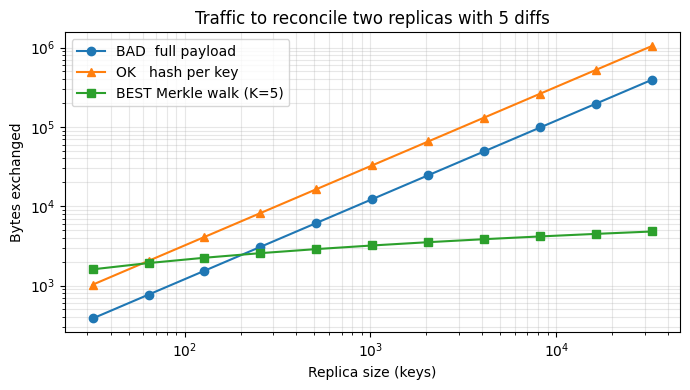

In [5]:
import matplotlib.pyplot as plt
import math

# Compare traffic across a range of dataset sizes with a FIXED number of diffs.
Ns = [2**k for k in range(5, 16)]
K = 5  # differing leaves
bad_bytes  = [n * 12 for n in Ns]                              # ~12 bytes per row (toy estimate)
ok_bytes   = [n * 32 for n in Ns]                              # 32-byte hash per row
best_bytes = [2 * 32 * K * max(1, math.ceil(math.log2(n))) for n in Ns]  # ~K·log N hashes, both peers

plt.figure(figsize=(7, 4))
plt.plot(Ns, bad_bytes,  label='BAD  full payload',  marker='o')
plt.plot(Ns, ok_bytes,   label='OK   hash per key',  marker='^')
plt.plot(Ns, best_bytes, label='BEST Merkle walk (K=5)', marker='s')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Replica size (keys)'); plt.ylabel('Bytes exchanged')
plt.title('Traffic to reconcile two replicas with 5 diffs')
plt.grid(True, which='both', alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()

## 🌍 Where this shows up in the real world

| System | What Merkle is used for |
| --- | --- |
| **Apache Cassandra** | `nodetool repair` uses Merkle trees to find divergent ranges between replicas. |
| **Amazon DynamoDB** | Background anti-entropy between partition replicas. |
| **Riak** | Active anti-entropy via per-partition hash trees. |
| **Git** | Each commit's tree object is a Merkle **DAG** (not a strict binary tree). |
| **Bitcoin / Ethereum** | Each block contains a Merkle root of its transactions; SPV clients verify with inclusion proofs. |
| **Certificate Transparency** | Append-only Merkle log of every TLS certificate. |
| **IPFS** | Content-addressed Merkle **DAG** for files and directories. |
| **ZFS / btrfs** | Checksummed block trees (Merkle-like) detect bit-rot on disk. |

Note: "Merkle **DAG**" (Git, IPFS) generalizes the binary-tree idea to any directed acyclic graph of hashes. Same core idea, different shape.

## ✅ Recap
- **Bad** (full payload) and **OK** (one hash per key) both cost `O(N)` regardless of how similar the replicas are.
- **Merkle walk** costs `O(K log N)` — essentially free when replicas are already in sync.
- Mind the padding: when N isn't a power of two, filter out padded leaf indices.
- Both replicas must agree on **leaf order** and **leaf serialization**; otherwise even identical data produces different roots.